# Model Project

## Question 1: A Consumer with two nests

In [3]:
from types import SimpleNamespace
import numpy as np
from scipy import optimize


from Consumer import ConsumerClass



#Find results
consumer=ConsumerClass()
opt = consumer.solve()


print("Results using L-BFGS-B:")
#Print shares spend on each item
print(f'Food share (s1):       {opt.s1:.4f}')
print(f'Bus share (s2):        {opt.s2:.4f}')
print(f'Train share (s3):      {opt.s3:.4f}')

#Check shares = 1
print(f'Share sum :            {opt.s1 + opt.s2 + opt.s3:.2f}')

#Print quantities
x1, x2, x3 = consumer.quantities(opt.s1, opt.w)

print(f'Food quantity (x1):    {x1:.4f}')
print(f'Bus quantity (x2):     {x2:.4f}')
print(f'Train quantity (x3):   {x3:.4f}')

print("Optimizer succeeded:  ", opt.res.success)

#Print final utility
print(f'Utility:               {opt.u:.4f}')

print("Results using grid:")

opt_grid = consumer.solve_grid()

#Print shares spend on each item
print(f'Food share (s1):       {opt_grid.s1:.4f}')
print(f'Bus share (s2):        {opt_grid.s2:.4f}')
print(f'Train share (s3):      {opt_grid.s3:.4f}')

#Check shares = 1
print(f'Share sum :            {opt_grid.s1 + opt_grid.s2 + opt_grid.s3:.2f}')

#Print quantities
x1, x2, x3 = consumer.quantities(opt_grid.s1, opt_grid.w)

print(f'Food quantity (x1):    {x1:.4f}')
print(f'Bus quantity (x2):     {x2:.4f}')
print(f'Train quantity (x3):   {x3:.4f}')

#Print utility 
print(f'Utility:               {opt_grid.u:.4f}')

print(opt.res.success)
print(opt.res.message)



Results using L-BFGS-B:
Food share (s1):       0.5356
Bus share (s2):        0.2041
Train share (s3):      0.2603
Share sum :            1.00
Food quantity (x1):    5.3562
Bus quantity (x2):     2.0408
Train quantity (x3):   1.7353
Optimizer succeeded:   True
Utility:               3.4017
Results using grid:
Food share (s1):       0.5377
Bus share (s2):        0.2021
Train share (s3):      0.2602
Share sum :            1.00
Food quantity (x1):    5.3769
Bus quantity (x2):     2.0212
Train quantity (x3):   1.7346
Utility:               3.4016
True
CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


The results for the L-BFGS-B and grid method are very similar, which seemingly should lead us to believe that the methods are done correctly. Both methods result in only positive quantities, and the quantity shares equal 1, once again indicating that the answer is possible.

## Question 2.1: Grid search

In [4]:
#Setup and importing
%load_ext autoreload
%autoreload 2

import pandas as pd

from types import SimpleNamespace
from functools import partial
import time

from scipy import optimize
from scipy.optimize import minimize
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import cm
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size':14})

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

%cd /Users/karolinazvingilaite/Downloads/ProgEcon-lectures-main-2/05_Optimization_and_RootFinding
from grid_solve import find_best_choice, find_best_choice_monotone


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[WinError 3] Den angivne sti blev ikke fundet: '/Users/karolinazvingilaite/Downloads/ProgEcon-lectures-main-2/05_Optimization_and_RootFinding'
c:\Users\alber\OneDrive\Documents\Polit\8. semester\Programmering for Economists\Model Project


ModuleNotFoundError: No module named 'grid_solve'

**Question 2.1.1: grid of N values for s_1 and w.**

In [ ]:
#%cd /Users/karolinazvingilaite/Downloads/ProgEcon-lectures-main-2/10_ModelProject/  
#i had to show path or else it would not work
from Consumer import ConsumerClass

model = ConsumerClass()

#defining the two grids, N values both 0 to 1:
s_1 = np.linspace(0, 1, N)
w = np.linspace(0, 1, N)

#Meshgrid for the two grids
s_1_grid, w_grid = np.meshgrid(s_1, w, indexing='ij')

#utility in the grid point:
u_grid = model.value_of_choice(s_1_grid, w_grid)

#finding the best point
i, j = np.unravel_index(np.argmax(u_grid), u_grid.shape)

#defining
s_1_best = s_1[i]
w_best = w[j]
s_1_best, s_2_best, s_3_best = model.shares(s_1_best, w_best)
u_best = u_grid[i, j]

#Print the results
print(f'best s1 = {s_1_best:.4f}')
print(f'best w  = {w_best:.4f}')
print(f'budget shares: s1={s_1_best:.4f}, '
      f's2={s_2_best:.4f}, s3={s_3_best:.4f}')
print(f'utility = {u_best:.4f}')



**Question 2.1.2: Plotting utility over the nested shares in 3D and contour plot**

In [ ]:
## Plotting nested shares in 3D
fig = plt.figure(figsize=(18, 7))

ax = fig.add_subplot(1, 2, 1, projection='3d')

surface = ax.plot_surface(s_1_grid, w_grid, u_grid, cmap=cm.jet)

#Plotting the solution point on the surface
ax.plot(
    s_1_best, w_best, u_best,
    'k*', markersize=8, zorder=10, label='grid solution (s_1, w, u) = ({:.4f}, {:.4f}, {:.4f})'.format(s_1_best, w_best, u_best)
)       #Added zorder=10 to make sure the point is on top of the surface

#inserting labels and title
ax.legend()             #Shows red dot placement
ax.set_xlabel('s1')
ax.set_ylabel('w')
ax.set_zlabel('utility')
ax.set_title('2.1.2a: Nested shares in 3D')


## Plotting the contour plot
cs = ax.contour(s_1_grid, w_grid, u_grid, 20, cmap=cm.jet, offset=np.min(u_grid))

ax = fig.add_subplot(1, 2, 2)

contour = ax.contourf(s_1_grid, w_grid, u_grid, 20, cmap=cm.jet)


# Contour colorbar and adding the solution point to the contour plot + red line in cbar
cbar_2d = fig.colorbar(contour, ax=ax, shrink=0.5, aspect=5)
cbar_2d.ax.axhline(u_best, color='cyan', linewidth=2)

ax.plot(
    s_1_best, w_best,
    'k*', markersize=8, label='grid solution (s_1, w) = ({:.4f}, {:.4f})'.format(s_1_best, w_best)
)

#inserting labels and title
ax.legend()              #to show red dot 
ax.set_xlabel('s1')
ax.set_ylabel('w')  
ax.set_title('2.1.2b: Contour plot of nested shares')

**Question 2.1.3: Trying different values of N**

In [ ]:
#Different values for N - see how the solutions changes.

N_values = [50, 100, 500, 1000]
results = []

for N in N_values:
    opt = model.solve_grid(N=N, do_print=False)

    results.append({
        'N': N,
        'N**2': N**2,
        's_1': opt.s1,
        'w': opt.w,
        'Utility': opt.u
    })

print('Calibration: Sigma_B = 0.4')
results = pd.DataFrame(results)
display(results.style.hide(axis='index'))   #Results without the index column first

As the number of grid points increases the calculation naturally becomes more precise, meaning the answer gets more stable as the grid gets finer. This means that the result/optimum point also gets more stable and precise as the grid gets finer.
However the improvement is not "smooth" as the real optimum lies between the grid points, and as the number of grid points increase, the closer the estimated optimum gets to the real optimum, as the candidate points get closer to the real optimum.

**Question 2.1.4: Comparing the two calibrations of Sigma_B**

In [ ]:
print(model.par.sigma_B)

model_substitutes = ConsumerClass(par={'sigma_B': 3.0})

print(model_substitutes.par.sigma_B)


## Different values for N - see how the solutions changes in a table with the new calibration of sigma_B = 3.0

N_values = [50, 100, 500, 1000]
results = []

for N in N_values:
    opt = model_substitutes.solve_grid(N=N, do_print=False)

    results.append({
        'N': N,
        'N**2': N**2,
        's_1': opt.s1,
        'w': opt.w,
        'Utility': opt.u
    })

print('Calibration: Sigma_B = 3.0')
results = pd.DataFrame(results)
display(results.style.hide(axis='index'))   #Results without the index column first

## To see where the calibration is more steep and where it is more flat, we plot the new calibration in 3D and contour plots.
model_substitutes = ConsumerClass(par={'sigma_B': 3.0})

#Meshgrid for the two grids
s_1_grid, w_grid = np.meshgrid(s_1, w, indexing='xy')

#utility in the grid point:
u_grid_sub = model_substitutes.value_of_choice(s_1_grid, w_grid)

#finding the best point
x, y = np.unravel_index(np.argmax(u_grid_sub), u_grid_sub.shape)

#defining
s_1_sub = s_1[x]
w_sub = w[y]
s_1_sub, s_2_sub, s_3_sub = model_substitutes.shares(s_1_sub, w_sub)
u_sub = u_grid_sub[x, y]

#Plotting nested shares in 3D
fig = plt.figure(figsize=(18, 7))
ax = fig.add_subplot(1, 2, 1, projection='3d')

surface_sub = ax.plot_surface(s_1_grid, w_grid, u_grid_sub, cmap=cm.jet)
ax.plot(
    s_1_sub, w_sub, u_sub,
    'k*', markersize=8, zorder=10, label='grid solution (s_1, w, u) = ({:.4f}, {:.4f}, {:.4f})'.format(s_1_sub, w_sub, u_sub)
)
#inserting labels and title
ax.legend()             #Shows red dot placement
ax.set_xlabel('s1')
ax.set_ylabel('w')
ax.set_zlabel('utility')
ax.set_title('2.1.4a: Nested shares in 3D with sigma_B = 3.0')

#Contour plot
cs_sub = ax.contour(s_1_grid, w_grid, u_grid_sub, 20, cmap=cm.jet, offset=np.min(u_grid_sub))

ax = fig.add_subplot(1, 2, 2)
contour_sub = ax.contourf(s_1_grid, w_grid, u_grid_sub, 20, cmap=cm.jet)

cbar_sub = fig.colorbar(contour_sub, ax=ax, shrink=0.5, aspect=5)
cbar_sub.ax.axhline(u_sub, color='cyan', linewidth=2)

ax.plot(
    s_1_sub, w_sub,
    'k*', markersize=8, label='grid solution (s_1, w) = ({:.4f}, {:.4f})'.format(s_1_sub, w_sub)
)

#inserting labels and title
ax.legend()              #to show red dot
ax.set_xlabel('s1')
ax.set_ylabel('w')
ax.set_title('2.1.4b: Contour plot of nested shares with sigma_B = 3.0')




We have two calibrations sigma_B being 0.4, meaning that bus and train are hard to substitute with eachother, and sigma_B being 3.0 being easy to substitute. When two products are easily interchangable, the utility does not change as much when either using the bus or the train. For any change in one good, the consumer can just compensate by switching to the other good. This is clear, when considering the table above with sigma_B, where the utility is relatively the same given the number of grid points and the same goes for s_1 and w. 

Looking at figures 2.1.4a anf 2.1.4b we can tell that the share of travel budget used on the bus (w-direction) is flat compared to the share of income spent on food (s_1-direction), which is more steep. Sigma_B determines how interchangeable/substitutable buses and trains are for the consumer, which therefore can affect how sensitive utility is to changes in w.

Therefore it is expected that calibration sigma_B = 3.0 is harder to optimize, as is has a good which has a flatter side/surface making it more difficult to indentify a optimum, compared to calibration sigma_B = 0.4 in figures 2.1.2a anf 2.1.2b.

## Question 2.2: L-BFGS-B

**Question 2.2.1:**

In [ ]:
#using the L-BFGS-B method to find the optimal solution, from Consumer.py
model = ConsumerClass()
opt_lbfgsb = model.solve()

#Printing results
print(f'Optimal food share (s1): {opt_lbfgsb.s1:.4f}')
print(f'Optimal bus share of travel budget (w): {opt_lbfgsb.w:.4f}')
print(f'Utility at the optimum: {opt_lbfgsb.u:.4f}')
print(f'Function evaluations: {opt_lbfgsb.res.nfev}')

#runtime
import time
start_time = time.time()
opt_lbfgsb = model.solve()
runtime = time.time() - start_time

print(f'Runtime: {runtime:.4f} seconds')


We see that the optimum found with L-BFGS-B is nearly identical to the optimum we found using grid search in question 2.1.1. 
The number of function evaluation with this is 18 compared to the past grid searches which was depended on N. This means for the grid, it considers N**2 of evaluations, in our case, this was between 2,500 and 1,000,000 function evaluations. 
Because of this, L-BFGS-B had a shorter run time, which makes it objectively more efficient. 

**Question 2.2.2: Convergence Path**

In [ ]:
#Solving for the convergence path using callback argument
s0 = np.array([0.5, 0.5])   #initial guess for the optimization
path = [s0.copy()]          #path to store the optimization steps

result = optimize.minimize(
    model.objective,
    s0,
    method='L-BFGS-B',
    bounds=((0.0, 1.0), (0.0, 1.0)),
    callback=lambda sk: path.append(sk.copy())  #Done as suggested in the question
)

path = np.asarray(path)    #converting to numpy array

#plotting the path on the contour plot
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(s_1_grid, w_grid, u_grid, 20, cmap=cm.jet)
fig.colorbar(contour, ax=ax)

#Plotting the convergence path and the final solution
ax.plot(
    path[:, 0], path[:, 1],
    'wo-', label='L-BFGS-B convergence path'
)

ax.plot(
    result.x[0], result.x[1],
    'k*', markersize=14,
    label='Final solution'
)

#labels and title
ax.set_xlabel('s1')
ax.set_ylabel('w')
ax.set_title('2.2.2a: L-BFGS-B convergence path')
ax.legend()
plt.show()

#distance to the final solution
final_point = result.x
distance = np.linalg.norm(path - final_point, axis=1)
iterations = np.arange(len(path))

#every iteration in a table from the initial guess to the final solution
iteration_table = pd.DataFrame({
    'Iteration': iterations,
    's1': path[:, 0],
    'w': path[:, 1],
    'Distance to final solution': distance
})

display(iteration_table.style
        .hide(axis='index')   #hiding the index column
        .format({
    's1': '{:.4f}',
    'w': '{:.4f}',
    'Distance to final solution': '{:.2e}'
}))

#plot distance on a log scale
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(iterations, np.maximum(distance, 1e-16), 'o-')  #the graph

#labels and title
ax.set_yscale('log')
ax.set_xlabel('Iterations')
ax.set_ylabel('Distance to final solution')
ax.set_xticks(iterations)
ax.set_title('2.2.2b: L-BFGS-B convergence on a log scale')

plt.show()

As we see in figure 2.2.2b the slowest progress is found between iteration 0 and 1, slowly becoming better, where the best is between iteration 3 and 4, where optimum is found.

**Question 2.2.3: Six different starting points**

In [ ]:
#defining six different starting points for solving
starts = {
    'middle (0.5, 0.5)': np.array([0.5, 0.5]),
    'corner (0, 0)': np.array([0.0, 0.0]),
    'corner (0, 1)': np.array([0.0, 1.0]),
    'corner (1, 0)': np.array([1.0, 0.0]),
    'corner (1, 1)': np.array([1.0, 1.0]),
    'interior (0.25, 0.75)': np.array([0.25, 0.75])
}

#including both calibrations of sigma_B
calibrations = {
    'sigma_B = 0.4': ConsumerClass(),
    'sigma_B = 3.0': ConsumerClass(par={'sigma_B': 3.0})
}

rows = []   #creating an empty list to store the results

for calibration, model_now in calibrations.items():  #going through the two calibrations...
    for name, s0_now in starts.items():              #...which goes through the six different starting points...

        res = optimize.minimize(                     #...which is solved using same model as before...
            model_now.objective,
            s0_now,
            method='L-BFGS-B',
            bounds=((0.0, 1.0), (0.0, 1.0))
        )

        rows.append({                                #...which is stored in the created list.
            'Calibration': calibration,
            'Starting point': name,
            'Final s1': res.x[0],
            'Final w': res.x[1],
            'Utility': -res.fun,
            'Iterations': res.nit,
            'Success': res.success
        })

six_start_table = pd.DataFrame(rows)

#showing the stored results in a table.
display(
    six_start_table.style
    .hide(axis='index')
    .format({
        'Final s1': '{:.4f}',
        'Final w': '{:.4f}',
        'Utility': '{:.4f}'
    })
)

As we can see from the table, we do not get the same solution for the different starting points. 
For each calibration and starting point we get a different number of interations and solution.
For sigma_B = 3.0 all starting points converge to the same solution, while the number of interations differ.
For sigma_B = 0.4 starting points differ, where corner (s1, w) = (1, 0) fails, because in the corner the utility function is flat and the optimization algorithm cannot find a direction to move in. Therefore, it concludes that it has found the optimum, even if it is not the global optimum. Same happens for corner (s1, w) = (0, 1), where the utility function is also flat. 
This is also hinted by the number of iterations.

**Question 2.2.4-2.2.5: Varying the settings**

In [ ]:
## a) ftol:
rows = []   #creating an empty list

for ftol in [10**(-i) for i in [4, 8, 12, 16]]:  #going through the different values of ftol
    res = optimize.minimize(
        model_now.objective,
        s0_now,
        method='L-BFGS-B',
        bounds=((0.0, 1.0), (0.0, 1.0)),
        options={'ftol': ftol}              #Now using ftol
    )

    rows.append({                           #storing the results in the list 
        'Setting': 'ftol',
        'Value': ftol,
        's1': res.x[0],
        'w': res.x[1],
        'Utility': -res.fun,
        'Function evaluations': res.nfev,
        'Iterations': res.nit,
    })

ftol_table = pd.DataFrame(rows)             #defining list as a dataframe

#displaying the results
display(
    ftol_table.style
    .hide(axis='index')
    .format({
        'Value': '{:.0e}',
        's1': '{:.5f}',
        'w': '{:.5f}',
        'Utility': '{:.5f}'
    })
)

## b) gtol:
rows = []   #creating an empty list

for gtol in [10**(-i) for i in [2, 5, 8, 12]]:  #going through the different values of gtol
    res = optimize.minimize(
        model_now.objective,
        s0_now,
        method='L-BFGS-B',
        bounds=((0.0, 1.0), (0.0, 1.0)),
        options={'gtol': gtol}              #Now using gtol
    )

    rows.append({                           #storing the results in the list 
        'Setting': 'gtol',
        'Value': gtol,
        's1': res.x[0],
        'w': res.x[1],
        'Utility': -res.fun,
        'Function evaluations': res.nfev,
        'Iterations': res.nit,
    })
gtol_table = pd.DataFrame(rows)             #defining list as a dataframe

#displaying the results
display(
    gtol_table.style
    .hide(axis='index')
    .format({
        'Value': '{:.0e}',
        's1': '{:.5f}',
        'w': '{:.5f}',
        'Utility': '{:.5f}'
    })
)

Overall, as the objective is to maximize utility, both settings yield the same. 
For ftol we would choose 10^-8 as it is the most precise, highest utility and lowest evaluations.
For gtol we would choose 10^-5, 10^-8 or 10^-12 as they all yield the same utility and evaluations, whereas 10^-2 yields a lower utility, meaning it did not reach optimum.

## Question 3: Relative prices and demand


**Question 3.1:**

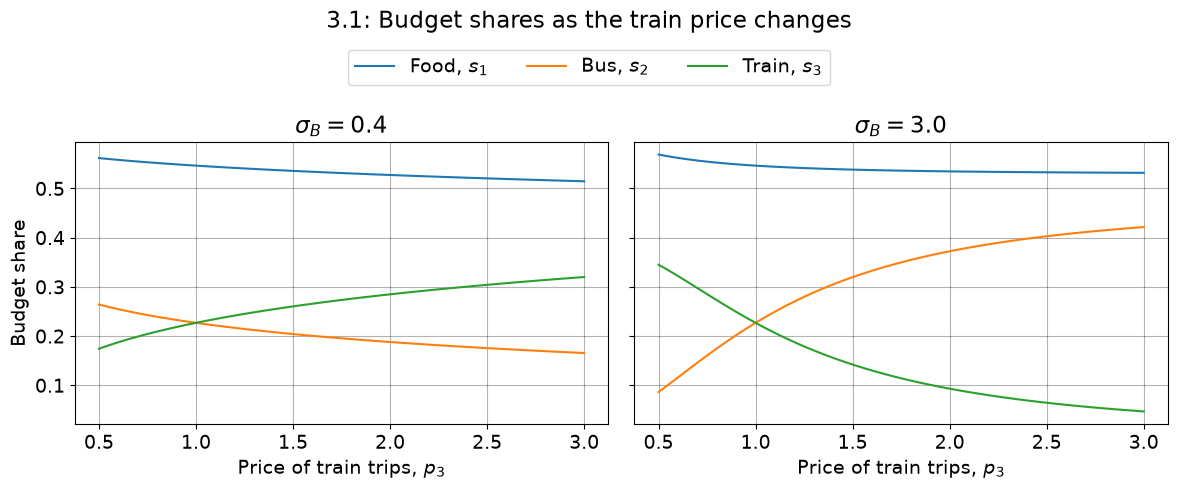

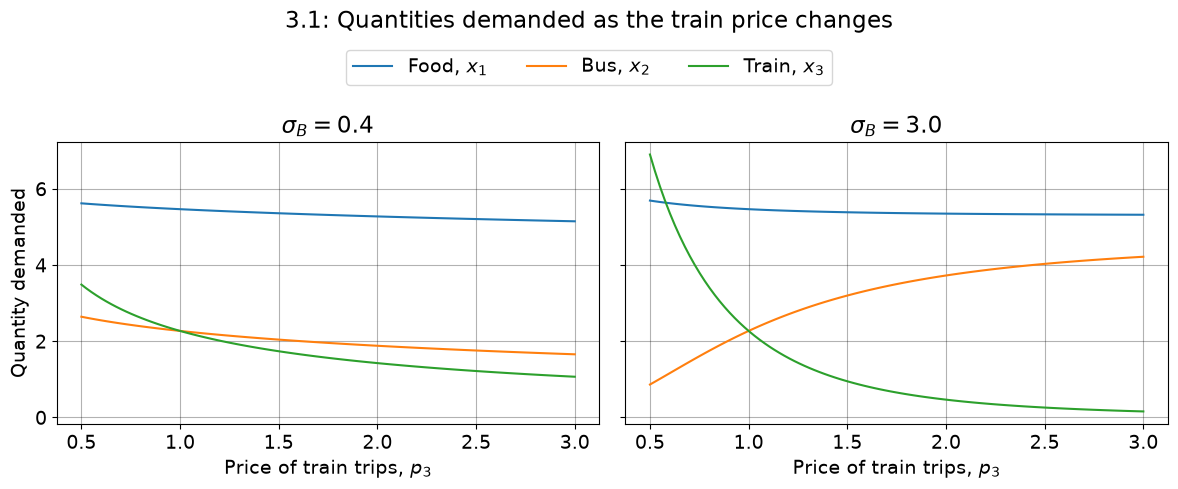

In [5]:
import matplotlib.pyplot as plt

p3_values = np.linspace(0.5, 3.0, 100)
sigma_B_values = (0.4, 3.0)

#Store the results for each calibration.
share_results = {}
quantity_results = {}

for sigma_B in sigma_B_values:
    shares = np.empty((len(p3_values), 3))
    quantities = np.empty((len(p3_values), 3))
    consumer_p = ConsumerClass(par={'sigma_B': sigma_B})
    s0 = None

    for i, p3 in enumerate(p3_values):
        consumer_p.par.p3 = p3
        opt_p = consumer_p.solve(s0=s0, do_print=False)
        shares[i] = [opt_p.s1, opt_p.s2, opt_p.s3]
        quantities[i] = consumer_p.quantities(opt_p.s1, opt_p.w)

        # Use the previous solution as the next starting point.
        s0 = np.array([opt_p.s1, opt_p.w])

    share_results[sigma_B] = shares
    quantity_results[sigma_B] = quantities

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, sigma_B in zip(axes, sigma_B_values):
    shares = share_results[sigma_B]
    ax.plot(p3_values, shares[:, 0], label='Food, $s_1$')
    ax.plot(p3_values, shares[:, 1], label='Bus, $s_2$')
    ax.plot(p3_values, shares[:, 2], label='Train, $s_3$')
    ax.set_title(fr'$\sigma_B={sigma_B}$')
    ax.set_xlabel('Price of train trips, $p_3$')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Budget share')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.92))
fig.suptitle('3.1: Budget shares as the train price changes')
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

# Plot the quantities demanded for both calibrations.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, sigma_B in zip(axes, sigma_B_values):
    quantities = quantity_results[sigma_B]
    ax.plot(p3_values, quantities[:, 0], label='Food, $x_1$')
    ax.plot(p3_values, quantities[:, 1], label='Bus, $x_2$')
    ax.plot(p3_values, quantities[:, 2], label='Train, $x_3$')
    ax.set_title(fr'$\sigma_B={sigma_B}$')
    ax.set_xlabel('Price of train trips, $p_3$')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Quantity demanded')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.92))
fig.suptitle('3.1: Quantities demanded as the train price changes')
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()




**Question 3.2:**

In the first calibration of the model, where $\sigma_B=0.4$, bus and train are complements, meaning the consumer buys the goods together. Therefore, as $p_3$ increases, the demand for both goods decrease, as the consumer can buy less trains, and in turn, they do not want to spend as much on busses. Although a price increase leads to less overall consumption trains (and busses), the train budget share increases. This is because the price rises faster than the quantity falls, and faster than income changes. 

In the second calibration, where $\sigma_B=3.0$, bus and train are substitutes, meaning the consumer buys one good instead of the other. Therefore, as the train gets more expensive, the consumer switches to using the bus, hence, the train budget share decreases significantly as train prices increase. 


**Question 3.3:**

In [ ]:
for sigma_B in sigma_B_values:
    consumer_q = ConsumerClass(par={'sigma_B': sigma_B})
    shares = share_results[sigma_B]

    bus_quantities = []

    for p3, share in zip(p3_values, shares):
        consumer_q.par.p3 = p3

        s1, s2, s3 = share
        w = s2 / (s2 + s3)  # Conditional bus share within travel

        x1, x2, x3 = consumer_q.quantities(s1, w)
        bus_quantities.append(x2)

    change = bus_quantities[-1] - bus_quantities[0]

    print(f"sigma_B = {sigma_B}")
    print(f"Bus quantity at p3 = {p3_values[0]:.1f}: {bus_quantities[0]:.3f}")
    print(f"Bus quantity at p3 = {p3_values[-1]:.1f}: {bus_quantities[-1]:.3f}")
    print(f"Change in bus-trip quantity: {change:.3f}")
    print()

In the first calibration, the number of bus trips the consumer takes decreases. In contrast, the number of bus trips increases in the second calibration. This follows what we would expect based on whether or not bus and train trips are complements or substitutes; for complements, as one good increases in price, the optimal quantity of the compliment good decreases, while the optimal quantity increases for substitutes.

The increase from being substitutes is larger than the decrease from being complements. This is due to the degree of substitution and complementing. 




**Question 3.4:**

In [ ]:
for sigma_B in sigma_B_values:
    consumer_food = ConsumerClass(par={'sigma_B': sigma_B})
    food_quantities = []

    for p3, share in zip(p3_values, share_results[sigma_B]):
        consumer_food.par.p3 = p3

        s1, s2, s3 = share
        w = s2 / (s2 + s3)

        x1, x2, x3 = consumer_food.quantities(s1, w)
        food_quantities.append(x1)

    change = food_quantities[-1] - food_quantities[0]

    print(f"sigma_B = {sigma_B}")
    print(f"Food quantity at p3 = {p3_values[0]:.1f}: {food_quantities[0]:.3f}")
    print(f"Food quantity at p3 = {p3_values[-1]:.1f}: {food_quantities[-1]:.3f}")
    print(f"Change in food quantity: {change:.3f}")
    print()

In both calibrations the food quantity only decreases slightly (though a little more in the first calibration). Food and travel are complements, meaning this decrease follows the expected outcome. This effect is much smaller on food than busses, due to the model's nested structure, as the price change being mostly absorbed within the travel nest.

Since the second calibration sees the two travel goods as substitutes, the decrease in food quantity is slightly smaller. This is due to the consumer being able to avoid the price increase in a much larger sense by switching to busses, meaning the travel nest "budget share" barely changed.

## Question 4: Lump-sum taxes and product taxes

**Question 4.1-4.2:**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from Government import GovernmentClass

tau_values = np.linspace(0.0, 3.0, 301)
sigma_B_values = (0.4, 3.0)

#Store the results for each calibration.
tau_results = {}



#The five product-tax systems
tax_scenarios = {
    'Food only': (1,),
    'Bus only': (2,),
    'Train only': (3,),
    'Bus and train': (2, 3),
    'All three goods': (1, 2, 3)
}

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    sharex=True,
    sharey=True
)

for ax, sigma_B in zip(axes, sigma_B_values):
  
    government = GovernmentClass(
        par={'sigma_B': sigma_B}
    )

    for label, goods in tax_scenarios.items():

        revenue_values = np.empty(len(tau_values))

        for i, tau in enumerate(tau_values):
            R, u = government.revenue_and_utility(
                tau,
                goods=goods
            )
            revenue_values[i] = R

        ax.plot(
            tau_values,
            revenue_values,
            label=label
        )

    ax.set_title(fr'$\sigma_B={sigma_B}$')
    ax.set_xlabel(r'Tax rate, $\tau$')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Tax revenue, $R$')

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=5,
    bbox_to_anchor=(0.5, 0.92)
)

fig.suptitle('4.1:Product-tax revenue', y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.84))

plt.show()


**Question 4.3:**

In [ ]:
#using grid to find the best tax rate
tau_grid = np.linspace(0.0, 3.0, 301)

rows = []  #starting a list

for sigma_B in [0.4, 3.0]:

    government = GovernmentClass(par={'sigma_B': sigma_B})

    for label, goods in tax_scenarios.items():

        revenue = np.array([
            government.revenue_and_utility(tau, goods=goods)[0]
            for tau in tau_grid
        ])

        i_max = np.argmax(revenue)

        #maximum tau = 3 means the curve is still rising
        if i_max < len(tau_grid) - 1:
            rows.append({
                'Calibration': f'sigma_B = {sigma_B}',
                'Tax instrument': label,
                'Revenue-maximizing rate': tau_grid[i_max],
                'Maximum revenue': revenue[i_max]
            })

max_revenue_table = pd.DataFrame(rows)   #storing


display(
    max_revenue_table.style
    .hide(axis='index')
    .format({
        'Revenue-maximizing rate': '{:.4f}',
        'Maximum revenue': '{:.4f}'
    })
)

From figure 4.1:
For sigma_B = 0.4 all five curves keep rising.
For sigma_B = 3.0, the bus only graph and train only graph have a top, where the rest keeps rising.
From table we see for the bus only graph that the tau is 0.86 with revenue 0.8721.
For the train only graph tau is 0.59 with revenue 0.259, meaning most a train ticket alone can ever raise is 0.259.


**Question 4.4:**

In [ ]:
tau_values = np.linspace(0.0, 3.0, 301)
T_values = np.linspace(0.0, 7.5, 301)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sigma_B in zip(axes, [0.4, 3.0]):

    government = GovernmentClass(par={'sigma_B': sigma_B})

    #prodyct taxes
    for label, goods in tax_scenarios.items():

        revenue_values = []
        utility_values = []

        for tau in tau_values:
            R, u = government.revenue_and_utility(tau, goods=goods)
            revenue_values.append(R)
            utility_values.append(u)

        ax.plot(revenue_values, utility_values, label=label)

    #lumpsum tax
    revenue_lump = []
    utility_lump = []

    for T in T_values:
        R, u = government.revenue_and_utility_lump_sum(T)
        revenue_lump.append(R)
        utility_lump.append(u)

    ax.plot(
        revenue_lump,
        utility_lump,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Lump-sum tax'
    )

    ax.set_title(fr'$\sigma_B = {sigma_B}$')
    ax.set_xlabel('Tax revenue, $R$')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Consumer utility')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels)

fig.suptitle('4.4: Utility & tax revenue')
fig.tight_layout()

plt.show()

The cheapest instruments are the lumpsum tax and equal tax for the three goods. 
This is because neither changes relative prices and all goods become equally expensive, reducing purchasing power with out changing the relative prices.optimize
As for the calibration, the more substitutable, like in the case of sigmaB = 3, the more the consumer is likely to switch to the cheaper good, lowering the utility. 
For the other calibration, the bus-only and train-only graphs mimic the others as substitution is not an option. The consumer is more likely to pay the tax and not change their consumption pattern, keeping utility higher.

**Question 4.5**

In [ ]:
R_target = 0.20   #The target revenue for the government


for sigma_B in [0.4, 3.0]:     #the two sigma_B calibrations

    government = GovernmentClass(par={'sigma_B': sigma_B})
    rows = []                   #starting a list again

    #prodcut taxes
    for label, goods in tax_scenarios.items():

        def revenue_gap(tau):
            R, u = government.revenue_and_utility(tau, goods=goods)
            return R - R_target

        root = optimize.root_scalar(    #using root finder
            revenue_gap,
            bracket=[1e-10, 0.5],
            method='brentq'
        )

        tau_star = root.root
        R, u = government.revenue_and_utility(tau_star, goods=goods)

        rows.append({
            'Instrument': label,
            'Tax rate / T': tau_star,
            'Revenue': R,
            'Utility': u
        })

    #target revenue equals T exactly
    R, u = government.revenue_and_utility_lump_sum(R_target)

    rows.append({
        'Instrument': 'Lump-sum tax',
        'Tax rate / T': R_target,
        'Revenue': R,
        'Utility': u
    })

    results_table = pd.DataFrame(rows)

    #ranking the results by the utility 
    results_table['Rank'] = (
        results_table['Utility']
        .rank(ascending=False, method='min')
        .astype(int)
    )

    results_table = results_table.sort_values('Rank')

    print(f'sigma_B = {sigma_B}')

    display(
        results_table.style
        .hide(axis='index')
        .format({
            'Tax rate / T': '{:.6f}',
            'Revenue': '{:.3f}',
            'Utility': '{:.6f}'
        })
    )

Depending on the calibration, bus and train share the bottom of the rankings. When they are poor substitutes, the utility is very close between the two, and the tax rate is around 8.1%.

In the other calibration, the tax rate is about 23.6% to raise the same revenue, which is why the utility is lower than bus. 


## Question 5: Extension

Another variable for drinks is included in the consumer decision. This is in a new nest, Groceries, with food where the two variables are compliments (with a much larger preference for food). The two nest that utility is now comprised of, groceries and travel, are compliments, meaning the previous substitution on food vs travel, $\sigma_A$, is the same, but now between the two nest. The previous weight on food, $\alpha$, is now the weight on groceries instead.

In [ ]:
import importlib
import Consumer

importlib.reload(Consumer)
ConsumerClass_drink = Consumer.ConsumerClass_drink

# Find results
consumer_d = ConsumerClass_drink()
opt = consumer_d.solve()

print('Results using L-BFGS-B:')

#The optimizer chooses sG, wF and wB.
#sG is the consumption/grocery share; wF and wB split the two lower nests.
print(f'Grocery share (sG):          {opt.sG:.4f}')
print(f'Food within groceries (wF): {opt.wF:.4f}')
print(f'Bus within travel (wB):      {opt.wB:.4f}')

#Final shares spent on each item
print(f'Food share (s1):       {opt.s1:.4f}')
print(f'Drink share (s2):      {opt.s2:.4f}')
print(f'Bus share (s3):        {opt.s3:.4f}')
print(f'Train share (s4):      {opt.s4:.4f}')

#Check that shares sum to one
print(f'Share sum:             {opt.s1 + opt.s2 + opt.s3 + opt.s4:.2f}')

#Quantities use the three nested choice variables
x1, x2, x3, x4 = consumer_d.quantities(opt.sG, opt.wF, opt.wB)

print(f'Food quantity (x1):    {x1:.4f}')
print(f'Drink quantity (x2):   {x2:.4f}')
print(f'Bus quantity (x3):     {x3:.4f}')
print(f'Train quantity (x4):   {x4:.4f}')
print(f'Utility:               {opt.u:.4f}')
print(f'Optimizer succeeded:   {opt.res.success}')
print(f'Optimizer message:     {opt.res.message}')

print()
print('Results using grid:')
opt_grid = consumer_d.solve_grid()

#Final shares spent on each item
print(f'Food share (s1):       {opt_grid.s1:.4f}')
print(f'Drink share (s2):      {opt_grid.s2:.4f}')
print(f'Bus share (s3):        {opt_grid.s3:.4f}')
print(f'Train share (s4):      {opt_grid.s4:.4f}')

#Check that shares sum to one
print(f'Share sum:             {opt_grid.s1 + opt_grid.s2 + opt_grid.s3 + opt_grid.s4:.2f}')

# Quantities from the grid solution
x1, x2, x3, x4 = consumer_d.quantities(
    opt_grid.sG, opt_grid.wF, opt_grid.wB
)

print(f'Food quantity (x1):    {x1:.4f}')
print(f'Drink quantity (x2):   {x2:.4f}')
print(f'Bus quantity (x3):     {x3:.4f}')
print(f'Train quantity (x4):   {x4:.4f}')
print(f'Utility:               {opt_grid.u:.4f}')


Once again the results show that they are possible and correct, due to the positive outouts and similar outcomes.